# Titanic Survival Analysis — Task 2
### Data Science / Data Analysis with Python Internship — Main Crafts Technology

**Workflow:** Load → Clean → Analyze → Visualize → Conclude

Dataset: `train.csv` — the classic Titanic passenger dataset (891 passengers, Kaggle).


## 1. Load Dataset

We load the Titanic dataset from **Kaggle**: downloaded manually from the [Kaggle Titanic competition page](https://www.kaggle.com/c/titanic/data) (`train.csv`), then uploaded into this Colab session.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload train.csv downloaded from Kaggle (https://www.kaggle.com/c/titanic/data)
from google.colab import files
uploaded = files.upload()

# Load into pandas
df = pd.read_csv('train.csv')

# Preview
df.head()

In [ ]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 2. Explore & Clean Data

Unlike Task 1's dataset, the Titanic dataset has real missing values. We check for them, then handle the most important one: **Age**.

In [ ]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Observation:** `Age` has 177 missing values, `Cabin` has 687 (mostly empty), and `Embarked` has 2. Since `Age` is important for our analysis (survival rate by age group), we fill missing ages with the **median age** rather than dropping those rows, which would lose valuable data. `Cabin` has too many missing values to be useful here, so we drop it. `Embarked` has very few missing rows, so we fill them with the most common port.

In [ ]:
# Handle missing Age values -> fill with median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop Cabin column (too many missing values to be useful)
df = df.drop(columns=['Cabin'])

# Fill missing Embarked values with the most common port (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Confirm no missing values remain (except intentionally dropped Cabin)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Observation:** After cleaning, the dataset has no missing values in the columns we need. We have 891 passenger records with details like age, sex, passenger class, fare, and survival outcome (`Survived`: 1 = survived, 0 = did not survive).

## 3. Analysis Questions

We now answer the three core analysis questions using the cleaned data.

### 3.1 Who survived more: males or females?

In [ ]:
survival_by_gender = df.groupby('Sex')['Survived'].mean() * 100
print("Survival rate by gender:")
print(survival_by_gender)

better_gender = survival_by_gender.idxmax()
print(f"\n{better_gender.capitalize()} passengers had a higher survival rate.")

Survival rate by gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Female passengers had a higher survival rate.


### 3.2 Did passenger class affect survival chances?

In [ ]:
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
print("Survival rate by passenger class:")
print(survival_by_class)

print("\nClear pattern: survival rate drops as passenger class number increases (1st class had the best access to lifeboats).")

Survival rate by passenger class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

Clear pattern: survival rate drops as passenger class number increases (1st class had the best access to lifeboats).


### 3.3 What was the survival rate by age group?

In [ ]:
# Create age group bins
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child (0-12)', 'Teen (13-18)', 'Adult (19-35)', 'Middle Age (36-60)', 'Senior (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

survival_by_age = df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100
print("Survival rate by age group:")
print(survival_by_age)

Survival rate by age group:
AgeGroup
Child (0-12)          57.971014
Teen (13-18)          42.857143
Adult (19-35)         35.327103
Middle Age (36-60)    40.000000
Senior (60+)          22.727273
Name: Survived, dtype: float64


## 4. Visualizations

We create three visualizations to support the analysis above, with a short explanation after each one.

### 4.1 Bar chart: survival by gender

/tmp/ipykernel_135/3506857507.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette=['#DD8452', '#4C72B0'])


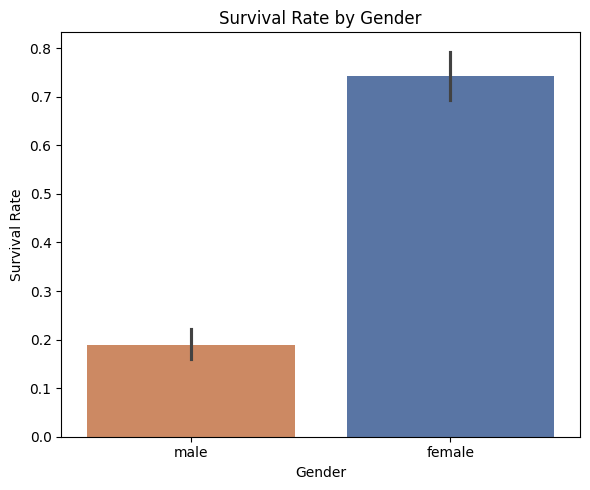

In [ ]:
plt.figure(figsize=(6,5))
sns.barplot(x='Sex', y='Survived', data=df, palette=['#DD8452', '#4C72B0'])
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.savefig('bar_survival_gender.png', dpi=150)
plt.show()

**What this shows:** Female passengers had a dramatically higher survival rate ~74% than male passengers ~19%. This reflects the "women and children first" evacuation protocol followed during the disaster.

### 4.2 Bar chart: survival by class

/tmp/ipykernel_135/2121432081.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='Blues_d')


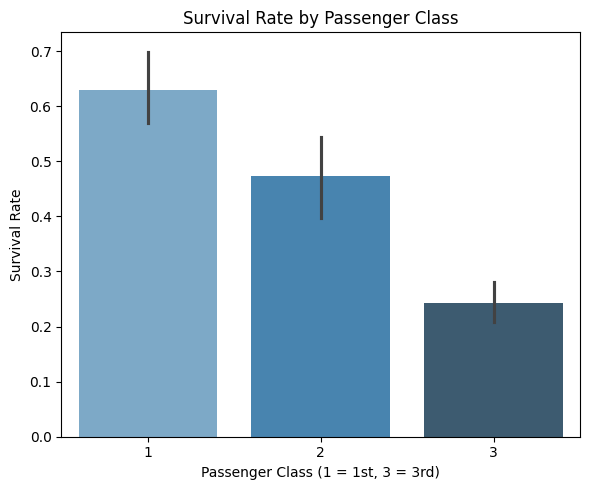

In [ ]:
plt.figure(figsize=(6,5))
sns.barplot(x='Pclass', y='Survived', data=df, palette='Blues_d')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1 = 1st, 3 = 3rd)')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.savefig('bar_survival_class.png', dpi=150)
plt.show()

**What this shows:** Survival rate drops steadily from 1st class ~63% to 2nd class ~47% to 3rd class ~24%. This highlights how socioeconomic status directly affected access to lifeboats and survival chances.

### 4.3 Histogram of passenger ages

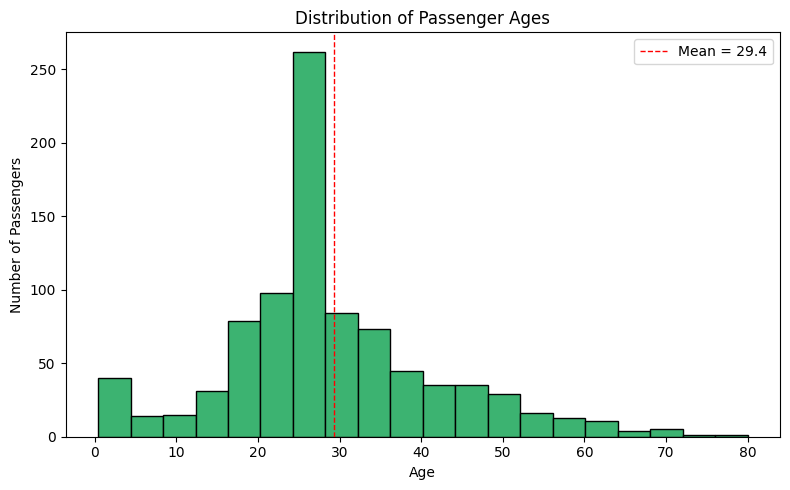

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.axvline(df['Age'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean = {df["Age"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.savefig('histogram_ages.png', dpi=150)
plt.show()

**What this shows:** Most passengers were between 20 and 40 years old, with the distribution peaking around the mean age of ~29. There's a smaller spike near the median-filled value since we imputed missing ages with the median — worth noting as a limitation of the cleaning approach.

## 5. Conclusion

Summary of findings:

- The dataset required real cleaning: missing `Age` values were filled with the median, `Cabin` was dropped due to excessive missingness, and `Embarked` was filled with the mode.
- **Gender was the single strongest predictor of survival** — female passengers survived at ~74% vs. ~19% for males, consistent with "women and children first" protocols.
- **Passenger class strongly affected survival chances** — 1st class passengers survived at more than double the rate of 3rd class passengers (~63% vs ~24%).
- **Age group also mattered** — children had a relatively higher survival rate compared to adults, though the effect was smaller than gender or class.

This completes the full data science workflow: **load → clean → analyze → visualize → conclude.**
